# Google AI Studio (Google for Developers)

[Google AI Studio Docs](https://aistudio.google.com/docs/)


In [1]:
# Connect to Google AI Studio
# https://aistudio.google.com/docs/music-generation

import os
import base64
from google import genai
from IPython.display import Audio, Image, display

# 1. Lokale .env Datei einlesen (überschreibt ggf. veraltete Umgebungsvariablen)
env_file = os.path.join(os.getcwd(), ".env")
if os.path.exists(env_file):
    with open(env_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                os.environ[k.strip()] = v.strip().strip("'\"")

# 2. Prüfen, ob der Dummy-Platzhalter noch drin steht
api_key = os.environ.get("GEMINI_API_KEY", "")
if "DEIN_VOLLSTAENDIGER_KEY" in api_key:
    raise ValueError("In deiner .env Datei steht noch der Platzhalter 'DEIN_VOLLSTAENDIGER_KEY'. Bitte trage dort deinen echten API-Key ein!")

# 3. Falls noch immer nicht gesetzt, im Notizbuch interaktiv abfragen
if not api_key:
    import getpass
    print("ℹ️ Bitte den Key im Eingabefeld GANZ OBEN am Bildschirmrand von VS Code eingeben und Enter drücken!")
    os.environ["GEMINI_API_KEY"] = getpass.getpass("Gemini API Key: ")

client = genai.Client()
print("✅ Client erfolgreich initialisiert!")


✅ Client erfolgreich initialisiert!


In [ ]:
# Generate music with Lyria 3.5
# https://aistudio.google.com/docs/music-generation
prompt = "A short instrumental acoustic guitar piece."
print(f"Generiere Musik für Prompt: '{prompt}'...")

interaction = client.interactions.create(
    model="lyria-3-clip-preview",
    input=prompt,
)

generated_audio = interaction.output_audio
if generated_audio:
    audio_bytes = base64.b64decode(generated_audio.data)
    with open("music.mp3", "wb") as f:
        f.write(audio_bytes)
    print("Musik erfolgreich als 'music.mp3' gespeichert!")
    display(Audio("music.mp3"))

lyrics = interaction.output_text
if lyrics:
    print(f"\nLyrics / Struktur:\n{lyrics}")

Generiere Musik für Prompt: 'A short instrumental acoustic guitar piece.'...
Musik erfolgreich als 'music.mp3' gespeichert!



Lyrics / Struktur:
<instrumental>


Generiere Bild für Prompt: 'A futuristic city with flying vehicles and glowing neon signs at sunset, cinematic digital art'...
Bild erfolgreich als 'banana_image.png' gespeichert!


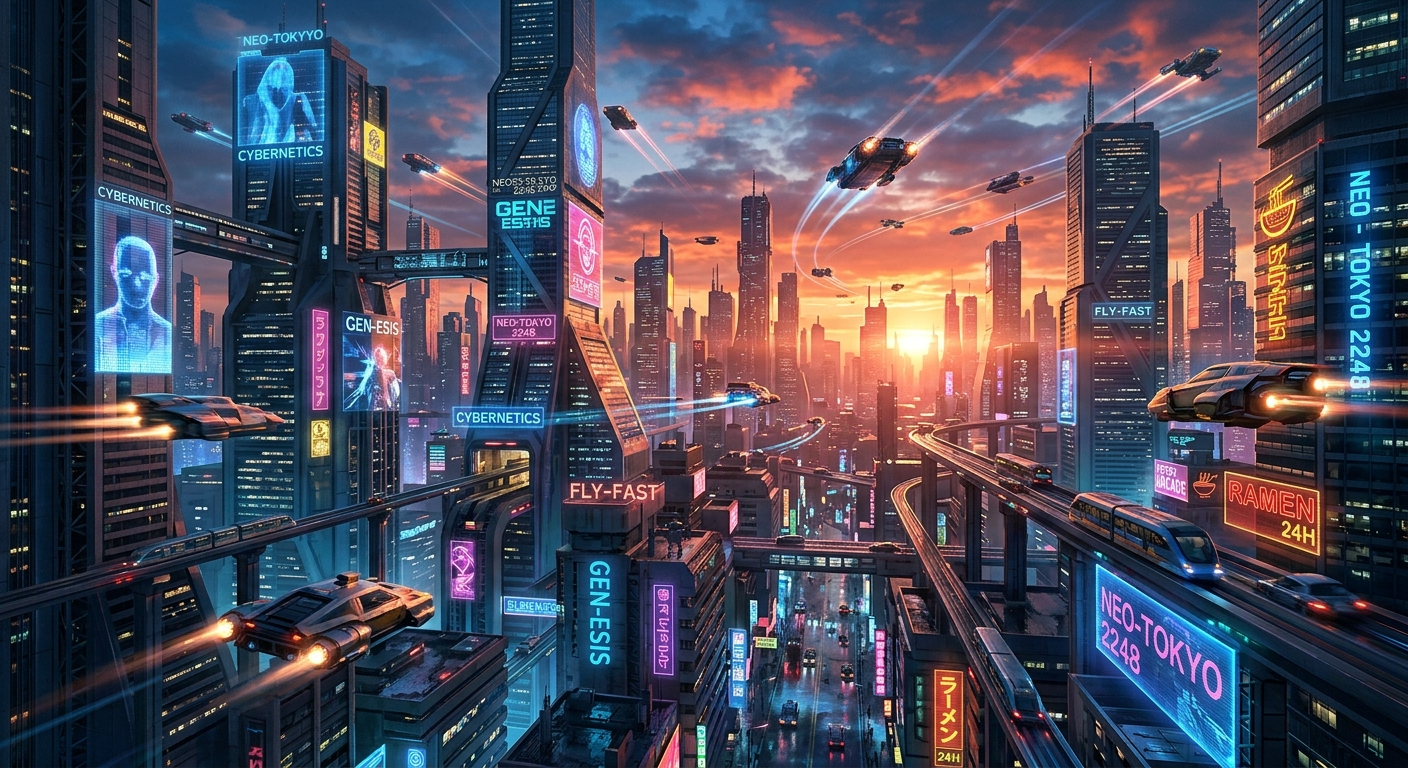

In [2]:
# Nano Banana - Image Generation
# https://aistudio.google.com/docs/image-generation
# Modell: "gemini-3.1-flash-image" (Nano Banana 2) oder "gemini-3-pro-image" (Nano Banana Pro)

prompt = "A futuristic city with flying vehicles and glowing neon signs at sunset, cinematic digital art"
print(f"Generiere Bild für Prompt: '{prompt}'...")

interaction = client.interactions.create(
    model="gemini-3.1-flash-image",  # Nano Banana 2
    input=prompt,
)

generated_image = interaction.output_image
if generated_image:
    image_bytes = base64.b64decode(generated_image.data)
    with open("banana_image.png", "wb") as f:
        f.write(image_bytes)
    print("Bild erfolgreich als 'banana_image.png' gespeichert!")
    display(Image("banana_image.png"))
else:
    print("Kein Bild zurückgegeben.")

output_text = interaction.output_text
if output_text:
    print(f"\nBeschreibung / Details:\n{output_text}")
